# Я художник, я так вижу, визуализация данных в питоне

# I. Numpy

### Импортируйте NumPy

In [1]:
import numpy as np

### Создайте одномерный массив размера 10, заполненный нулями и пятым элемент равным 1. Трансформируйте в двумерный массив.

In [2]:
a = np.zeros(10)
a[4] = 1                 # пятый элемент (индексация с нуля)
a2d = a.reshape(2, 5)    # 1D -> 2D без копирования данных
print(a)
a2d

[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]


array([[0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0.]])

### Создайте одномерный массив со значениями от 10 до 49 и разверните его (первый элемент становится последним). Найдите в нем все четные элементы.

In [3]:
b = np.arange(10, 50)          # [10, 50): 10..49
b_rev = b[::-1]                # разворот
evens = b_rev[b_rev % 2 == 0]  # отбор чётных по маске
print("развёрнутый:", b_rev)
print("чётные:", evens)

развёрнутый: [49 48 47 46 45 44 43 42 41 40 39 38 37 36 35 34 33 32 31 30 29 28 27 26
 25 24 23 22 21 20 19 18 17 16 15 14 13 12 11 10]
чётные: [48 46 44 42 40 38 36 34 32 30 28 26 24 22 20 18 16 14 12 10]


### Создайте двумерный массив 3x3 со значениями от 0 до 8

In [4]:
c = np.arange(9).reshape(3, 3)
c

array([[0, 1, 2],
       [3, 4, 5],
       [6, 7, 8]])

### Создайте массив 4x3x2 со случайными значениями. Найти его минимум и максимум.

In [5]:
np.random.seed(42)                 # воспроизводимость
d = np.random.random((4, 3, 2))
print("min:", d.min())
print("max:", d.max())

min: 0.020584494295802447
max: 0.9699098521619943


### Создайте два двумерных массива размерами 6x4 и 4x3 и произведите их матричное умножение. 

In [6]:
np.random.seed(0)
m1 = np.random.rand(6, 4)
m2 = np.random.rand(4, 3)
prod = m1 @ m2      # (6x4) @ (4x3) -> (6x3)
print("форма результата:", prod.shape)
prod

форма результата: (6, 3)


array([[1.2097223 , 1.20133563, 0.98672594],
       [1.28294382, 0.96371537, 1.07895623],
       [0.98629907, 1.4396844 , 0.98495274],
       [1.00988776, 0.90316036, 0.55145802],
       [1.48935158, 1.06626197, 1.24046098],
       [1.43645202, 1.41523686, 1.16425529]])

### Создайте случайный двумерный массив 7x7, найти у него среднее и стандартное оклонение. Нормализуйте этот массив.

In [7]:
np.random.seed(1)
e = np.random.rand(7, 7)
mean = e.mean()
std = e.std()
print("среднее:", round(mean, 4), "| стандартное отклонение:", round(std, 4))
e_norm = (e - mean) / std    # z-нормализация: mean~0, std~1
print("после нормализации: среднее =", round(e_norm.mean(), 4), "| std =", round(e_norm.std(), 4))
e_norm

среднее: 0.4739 | стандартное отклонение: 0.3045
после нормализации: среднее = 0.0 | std = 1.0


array([[-0.18662126,  0.80937782, -1.55568228, -0.56324385, -1.07413393,
        -1.25283202, -0.94440777],
       [-0.42128919, -0.25313405,  0.21333404, -0.17948707,  0.69409838,
        -0.88466789,  1.32754576],
       [-1.4661212 ,  0.6456551 , -0.18569259,  0.27859425, -1.09504859,
        -0.90552282,  1.07346507],
       [ 1.62356536, -0.52682071,  0.71742393,  1.32187034,  1.38169387,
        -1.27678566, -1.42780793],
       [-0.9983607 ,  1.32762808, -1.23310188, -0.17320471,  1.58950514,
         0.19477555,  0.71596097],
       [-0.5199527 ,  0.69830639,  1.18472545, -1.49600196,  0.90730156,
         1.69121101,  0.90080394],
       [-0.63512261,  1.03581498, -1.21707942, -0.08524389,  1.42763108,
        -0.59187382, -0.61104758]])

# II. Pandas

### Импортируйте: pandas, matplotlib, seaborn

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()   # стиль оформления графиков по умолчанию

### Загрузите датасет Tips из набора датасетов seaborn

In [9]:
tips = sns.load_dataset('tips')

### Посмотрите на первые 5 строчек

In [10]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### Узнайте сколько всего строчек и колонок в данных

In [11]:
tips.shape   # (строки, колонки)

(244, 7)

### Проверьте есть ли пропуски в данных

In [12]:
tips.isnull().sum()   # число пропусков по колонкам

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

### Посмотрите на распределение числовых признаков

In [13]:
tips.describe()   # статистика по числовым признакам

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


### Найдите максимальное значение 'total_bill'

In [14]:
tips['total_bill'].max()

np.float64(50.81)

### Найдите количество курящих людей

In [15]:
(tips['smoker'] == 'Yes').sum()

np.int64(93)

### Узнайте какой средний 'total_bill' в зависимости от 'day'

In [16]:
tips.groupby('day', observed=True)['total_bill'].mean()

day
Thur    17.682742
Fri     17.151579
Sat     20.441379
Sun     21.410000
Name: total_bill, dtype: float64

### Отберите строчки с 'total_bill' больше медианы и узнайте какой средний 'tip' в зависимости от 'sex'

In [17]:
median_bill = tips['total_bill'].median()
above = tips[tips['total_bill'] > median_bill]   # чеки выше медианы
above.groupby('sex', observed=True)['tip'].mean()

sex
Male      3.756404
Female    3.663939
Name: tip, dtype: float64

### Преобразуйте признак 'smoker' в бинарный (0-No, 1-Yes)

In [18]:
tips['smoker_bin'] = tips['smoker'].map({'No': 0, 'Yes': 1})
tips[['smoker', 'smoker_bin']].head()

,smoker,smoker_bin
0,No,0
1,No,0
2,No,0
3,No,0
4,No,0


# III. Visualization

### Постройте гистограмму распределения признака 'total_bill'

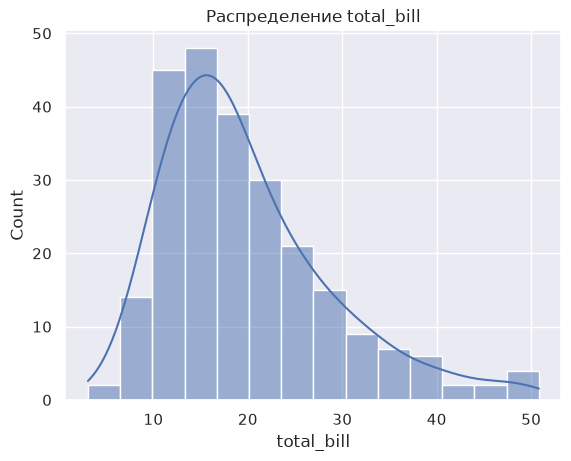

In [19]:
sns.histplot(data=tips, x='total_bill', kde=True)
plt.title('Распределение total_bill')
plt.show()

### Постройте scatterplot, представляющий взаимосвязь между признаками 'total_bill' и 'tip'

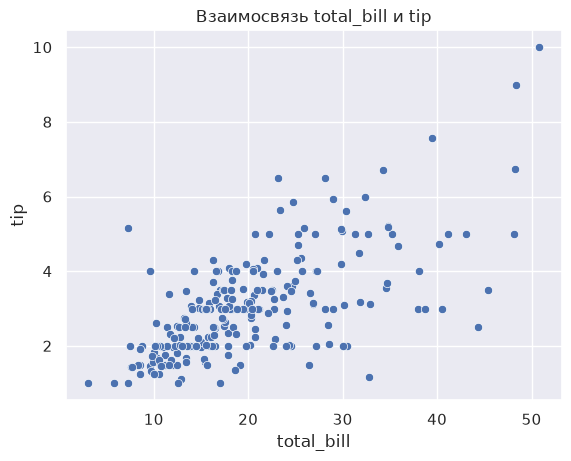

In [20]:
sns.scatterplot(data=tips, x='total_bill', y='tip')
plt.title('Взаимосвязь total_bill и tip')
plt.show()

### Постройте pairplot

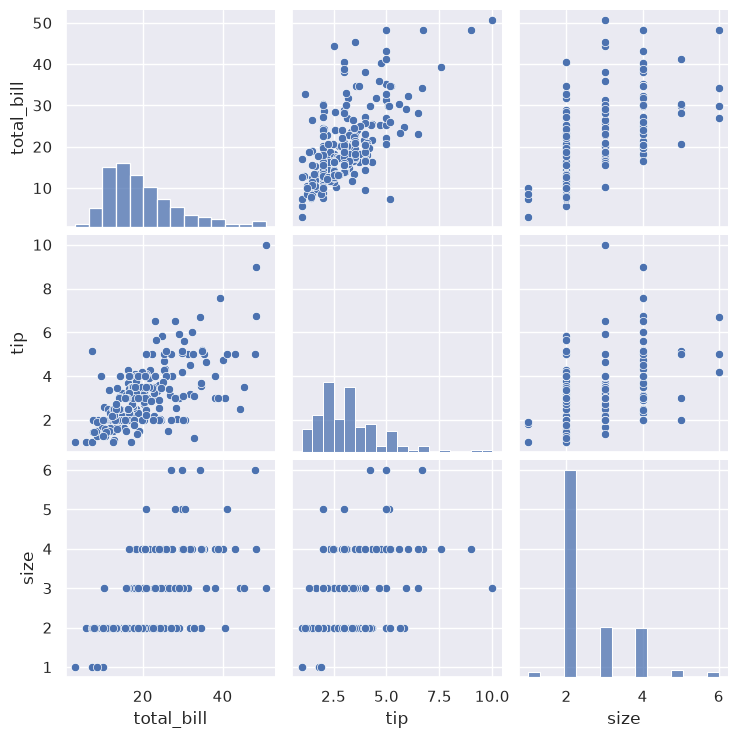

In [21]:
sns.pairplot(tips)   # попарные scatter + гистограммы по диагонали
plt.show()

### Постройте график взаимосвязи между признаками 'total_bill' и 'day'

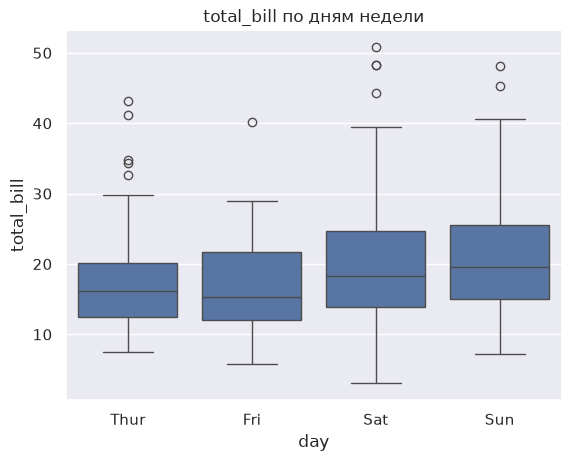

In [22]:
# категория x число: boxplot показывает медиану, квартили и выбросы
sns.boxplot(data=tips, x='day', y='total_bill')
plt.title('total_bill по дням недели')
plt.show()

### Постройте две гистограммы распределения признака 'tip' в зависимости от категорий 'time'

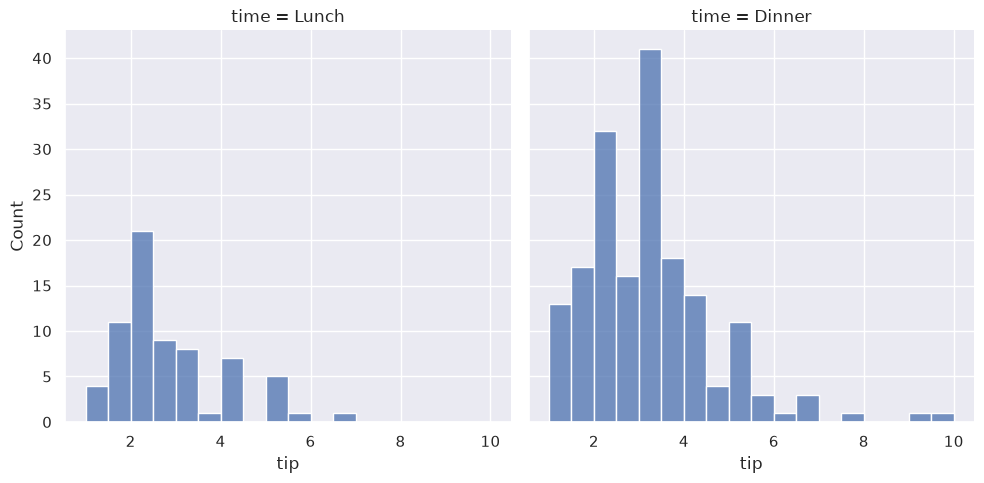

In [23]:
# col='time' -> отдельная гистограмма на каждую категорию
sns.displot(data=tips, x='tip', col='time')
plt.show()

### Постройте два графика scatterplot, представляющих взаимосвязь между признаками 'total_bill' и 'tip' один для Male, другой для Female и раскрасьте точки в зависимоти от признака 'smoker'

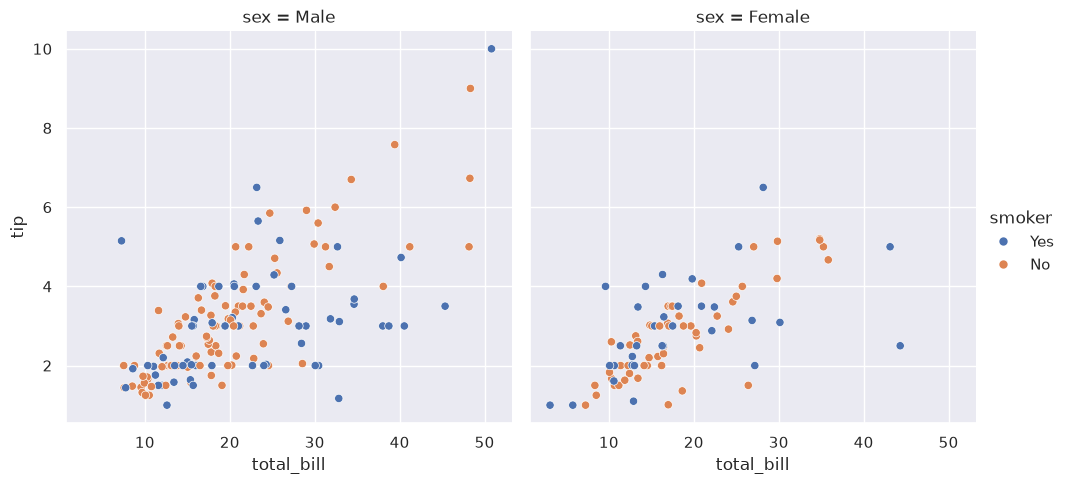

In [24]:
# col='sex' -> два графика; hue='smoker' -> цвет точек по курению
sns.relplot(data=tips, x='total_bill', y='tip', col='sex', hue='smoker', kind='scatter')
plt.show()

## Сделайте выводы по анализу датасета и построенным графикам. По желанию можете продолжить анализ данных и также отразить это в выводах.

## Выводы

**По данным.** Датасет `tips` — 244 чека из ресторана, 7 признаков, **пропусков нет**. Числовые признаки: `total_bill` (счёт), `tip` (чаевые), `size` (число гостей). Категориальные: `sex`, `smoker`, `day`, `time`.

**Основные наблюдения:**

- **Счёт и чаевые связаны положительно** — корреляция `total_bill`↔`tip` ≈ **0.68**. На scatterplot видно облако, вытянутое по диагонали: чем больше счёт, тем больше чаевые. Это самая сильная зависимость в данных.
- **Распределение `total_bill` скошено вправо**: большинство чеков в районе 10–20, но есть длинный «хвост» дорогих (максимум **50.81**). Средний размер компании — ~2.6 человека.
- **По дням недели** средний счёт выше в выходные: Sat ≈ 20.4, Sun ≈ 21.4 против Thur/Fri ≈ 17. В выходные люди тратят больше — вероятно, ужины большими компаниями.
- **Курящих** в выборке **93 из 244** (~38%). При этом доля чаевых от счёта у курящих и некурящих почти одинакова (~16%) — курение практически не влияет на щедрость.
- **Пол** заметной разницы не даёт: среди «дорогих» чеков (выше медианы 17.8) средние чаевые у мужчин 3.76, у женщин 3.66 — разница в пределах шума.
- **Время суток**: доля чаевых в обед (Lunch ≈ 16.4%) чуть выше, чем на ужине (Dinner ≈ 16.0%), но разница мизерная. Ужинов в датасете значительно больше.

**Итог.** Главный драйвер размера чаевых — это **сумма счёта**; остальные признаки (пол, курение, время, день) влияют слабо. Если бы стояла задача предсказать `tip`, `total_bill` был бы самым важным признаком.